# Proyecto Final - Bank Marketing

**Tema:** Analisis predictivo de aceptacion de depositos bancarios a plazo mediante campanas de telemarketing.

**Pregunta principal:** Que caracteristicas del cliente y de la campana de marketing influyen mas en que una persona acepte un deposito bancario a plazo?

**Dataset:** Bank Marketing Dataset - UCI Machine Learning Repository.

Este notebook esta organizado segun los procedimientos minimos solicitados por el profesor.

## 1. Instalacion y carga de librerias

Si alguna libreria no esta instalada, ejecuta en una terminal de VS Code: `pip install -r ../requirements.txt` desde la carpeta principal del proyecto.

In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR

import missingno as msno
# La grafica tipo UpSet se dibuja manualmente para evitar incompatibilidades de color en algunas versiones de upsetplot/matplotlib.

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

## 2. Carga del dataset

Se carga el archivo local `bank-full.csv`, descargado desde UCI Machine Learning Repository. El archivo usa separador `;`, por eso se indica `sep=';'`.

In [37]:
from pathlib import Path

possible_paths = [
    Path('../data/bank/bank-full.csv'),
    Path('data/bank/bank-full.csv'),
    Path.cwd() / '../data/bank/bank-full.csv',
    Path.cwd() / 'data/bank/bank-full.csv'
]

data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError('No se encontro bank-full.csv. Verifica que exista en data/bank/bank-full.csv')

df = pd.read_csv(data_path, sep=';')
print(f'Dataset cargado desde: {data_path.resolve()}')
df.head()

Dataset cargado desde: C:\Users\David De Los Santos\Documents\Codex\2026-07-05\ne\outputs\bank_marketing_project\data\bank\bank-full.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [38]:
df.shape

(45211, 17)

## 3. Analisis preliminar del dataset

Incluye dimension, tipos de datos, estadisticas descriptivas y primeras observaciones.

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [40]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [41]:
df['y'].value_counts(normalize=True).rename('proporcion')

y
no     0.883015
yes    0.116985
Name: proporcion, dtype: float64

## 4. Visualizacion de datos

Graficas de categorias, distribuciones y agrupaciones relevantes.

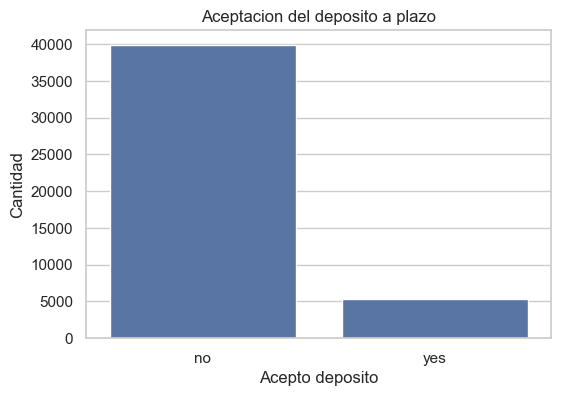

In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y')
plt.title('Aceptacion del deposito a plazo')
plt.xlabel('Acepto deposito')
plt.ylabel('Cantidad')
plt.show()

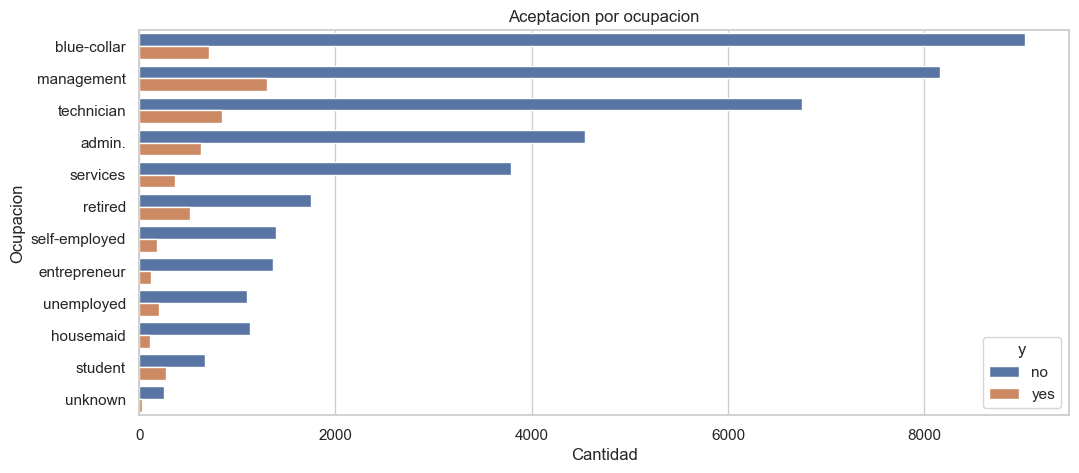

In [43]:
plt.figure(figsize=(12, 5))
order = df['job'].value_counts().index
sns.countplot(data=df, y='job', hue='y', order=order)
plt.title('Aceptacion por ocupacion')
plt.xlabel('Cantidad')
plt.ylabel('Ocupacion')
plt.show()

In [44]:
fig = px.histogram(df, x='age', color='y', nbins=35, barmode='overlay', title='Distribucion de edad por aceptacion')
fig.show()

In [45]:
fig = px.box(df, x='y', y='duration', color='y', title='Duracion de llamada segun aceptacion')
fig.show()

## 5. Analisis de valores faltantes

UCI indica que el dataset no tiene faltantes explicitos. Para cumplir el analisis solicitado, las categorias `unknown` se interpretan como datos no informados y se convierten a `NaN`.

In [46]:
df_missing = df.replace('unknown', np.nan)
missing_summary = df_missing.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

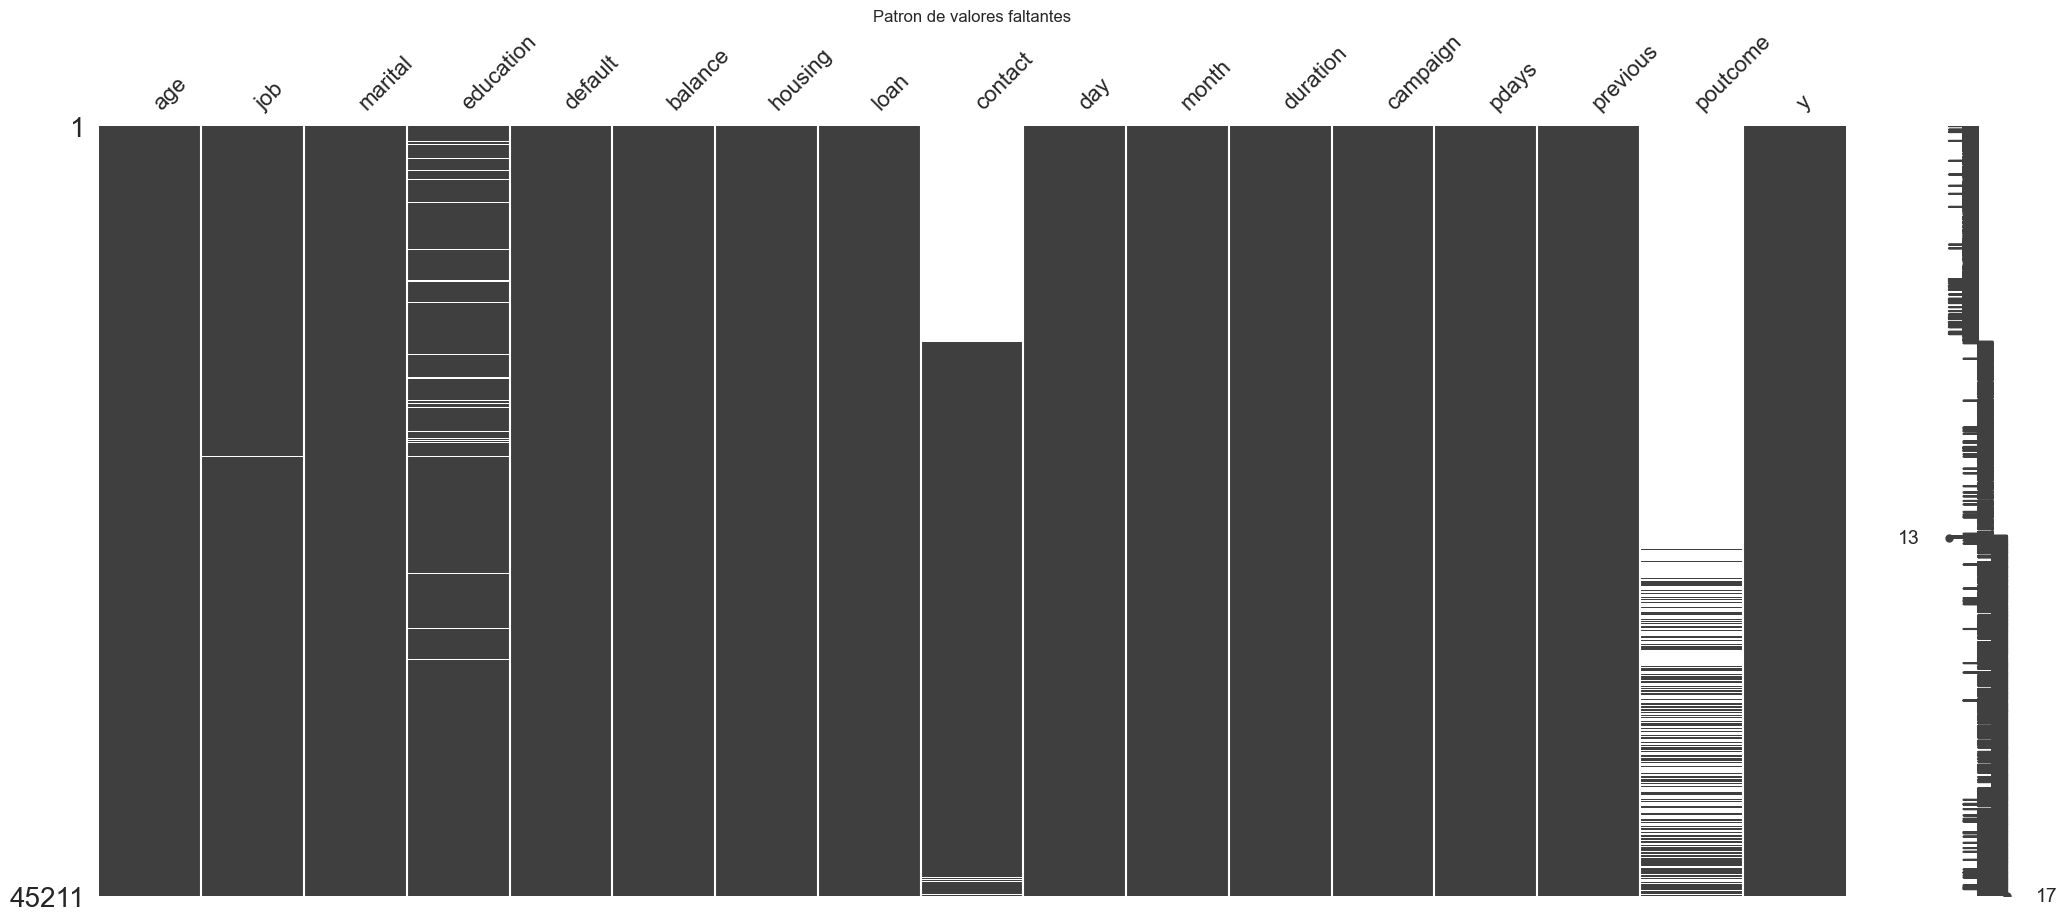

In [47]:
msno.matrix(df_missing)
plt.title('Patron de valores faltantes')
plt.show()

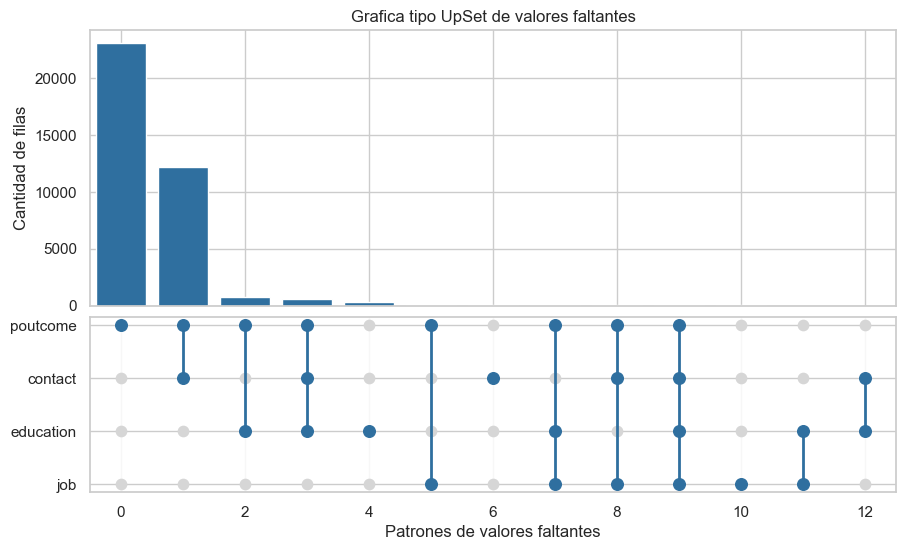

In [48]:
missing_cols = missing_summary[missing_summary > 0].index.tolist()

if missing_cols:
    missing_patterns = df_missing[missing_cols].isna()
    pattern_counts = missing_patterns.value_counts().reset_index(name='conteo')
    pattern_counts = pattern_counts[pattern_counts[missing_cols].any(axis=1)]
    pattern_counts = pattern_counts.sort_values('conteo', ascending=False).head(15).reset_index(drop=True)
    
    if len(pattern_counts) > 0:
        x = np.arange(len(pattern_counts))
        fig = plt.figure(figsize=(max(9, len(pattern_counts) * 0.8), 6))
        grid = fig.add_gridspec(2, 1, height_ratios=[2.2, 1.4], hspace=0.05)
        ax_bar = fig.add_subplot(grid[0])
        ax_matrix = fig.add_subplot(grid[1], sharex=ax_bar)
        
        ax_bar.bar(x, pattern_counts['conteo'], color='#2f6f9f')
        ax_bar.set_ylabel('Cantidad de filas')
        ax_bar.set_title('Grafica tipo UpSet de valores faltantes')
        ax_bar.tick_params(axis='x', labelbottom=False)
        
        y_positions = np.arange(len(missing_cols))[::-1]
        for row, col in enumerate(missing_cols):
            y = y_positions[row]
            active = pattern_counts[col].to_numpy(dtype=bool)
            ax_matrix.scatter(x[~active], np.full((~active).sum(), y), color='#d6d6d6', s=55)
            ax_matrix.scatter(x[active], np.full(active.sum(), y), color='#2f6f9f', s=70)
        
        for idx, row in pattern_counts.iterrows():
            active_y = [y_positions[i] for i, col in enumerate(missing_cols) if bool(row[col])]
            if len(active_y) > 1:
                ax_matrix.plot([idx, idx], [min(active_y), max(active_y)], color='#2f6f9f', linewidth=2)
        
        ax_matrix.set_yticks(y_positions)
        ax_matrix.set_yticklabels(missing_cols)
        ax_matrix.set_xlabel('Patrones de valores faltantes')
        ax_matrix.set_xlim(-0.5, len(pattern_counts) - 0.5)
        ax_matrix.grid(axis='x', alpha=0.15)
        plt.show()
    else:
        print('No hay patrones de faltantes para graficar.')
else:
    print('No hay columnas con valores faltantes.')

## 6. Eliminacion o imputacion de datos faltantes

Segun la indicacion del profesor, se consideran para eliminar variables con mas de 250 valores faltantes. En este dataset, revisaremos ese criterio y justificaremos las decisiones.

In [49]:
cols_mas_250 = missing_summary[missing_summary > 250].index.tolist()
cols_mas_250

['poutcome', 'contact', 'education', 'job']

In [50]:
# Decision inicial: no eliminar automaticamente columnas importantes para el analisis.
# Se imputaran categoricas con la moda y numericas con la mediana dentro de los pipelines.
df_clean = df_missing.copy()
df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## 7. Analisis de correlacion

Se presentan al menos dos enfoques: correlacion Pearson entre variables numericas y relacion de variables con la aceptacion usando una version binaria de `y`.

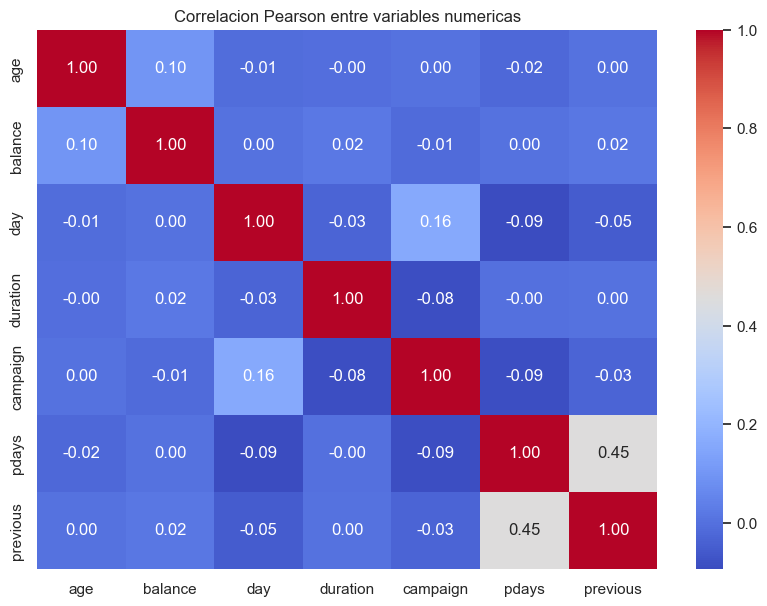

In [51]:
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr = df_clean[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlacion Pearson entre variables numericas')
plt.show()

In [52]:
df_corr_target = df_clean.copy()
df_corr_target['y_binary'] = df_corr_target['y'].map({'no': 0, 'yes': 1})
target_corr = df_corr_target[num_cols + ['y_binary']].corr()['y_binary'].sort_values(ascending=False)
target_corr

y_binary    1.000000
duration    0.394521
pdays       0.103621
previous    0.093236
balance     0.052838
age         0.025155
day        -0.028348
campaign   -0.073172
Name: y_binary, dtype: float64

## 8. Modelos de clasificacion

Variable categorica objetivo: `y`.

Modelos propuestos: Random Forest Classifier y KNN Classifier.

In [53]:
target_class = 'y'
X_class = df_clean.drop(columns=[target_class])
y_class = df_clean[target_class]

categorical_cols = X_class.select_dtypes(include='object').columns.tolist()
numeric_cols = X_class.select_dtypes(include=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [54]:
classification_models = {
    'Random Forest': RandomForestClassifier(n_estimators=120, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=7)
}

classification_results = []
trained_classification_models = {}

for name, model in classification_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train_c, y_train_c)
    trained_classification_models[name] = pipe
    
    pred_train = pipe.predict(X_train_c)
    pred_test = pipe.predict(X_test_c)
    
    classification_results.append({
        'modelo': name,
        'accuracy_train': accuracy_score(y_train_c, pred_train),
        'accuracy_test': accuracy_score(y_test_c, pred_test)
    })

pd.DataFrame(classification_results)

,modelo,accuracy_train,accuracy_test
0,Random Forest,0.997484,0.898153
1,KNN,0.913985,0.898043


Mejor clasificador: Random Forest
              precision    recall  f1-score   support

          no       0.95      0.93      0.94      7985
         yes       0.56      0.62      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.78      0.77      9043
weighted avg       0.90      0.90      0.90      9043



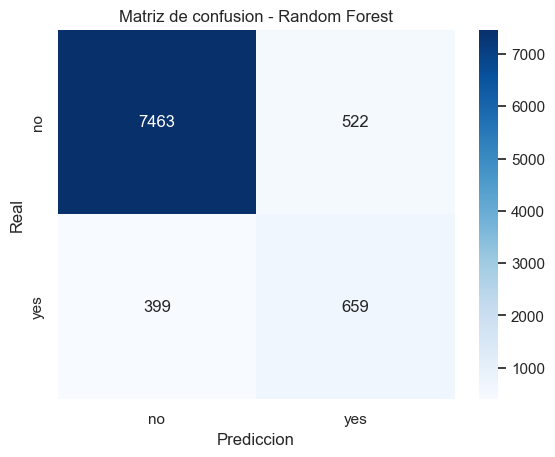

In [55]:
best_clf_name = pd.DataFrame(classification_results).sort_values('accuracy_test', ascending=False).iloc[0]['modelo']
best_clf = trained_classification_models[best_clf_name]
pred_test_best = best_clf.predict(X_test_c)

print('Mejor clasificador:', best_clf_name)
print(classification_report(y_test_c, pred_test_best))

cm = confusion_matrix(y_test_c, pred_test_best, labels=['no', 'yes'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
plt.title(f'Matriz de confusion - {best_clf_name}')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

## 9. Modelos de regresion

Variable continua objetivo sugerida: `balance`.

Modelos propuestos: Random Forest Regressor y SVR.

In [56]:
target_reg = 'balance'
X_reg = df_clean.drop(columns=[target_reg, 'y'])
y_reg = df_clean[target_reg]

categorical_cols_reg = X_reg.select_dtypes(include='object').columns.tolist()
numeric_cols_reg = X_reg.select_dtypes(include=np.number).columns.tolist()

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols_reg),
    ('cat', categorical_transformer, categorical_cols_reg)
])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [57]:
regression_models = {
    'Random Forest Regressor': RandomForestRegressor(n_estimators=120, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.2)
}

regression_results = []
trained_regression_models = {}

for name, model in regression_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor_reg), ('model', model)])
    pipe.fit(X_train_r, y_train_r)
    trained_regression_models[name] = pipe
    
    pred_train = pipe.predict(X_train_r)
    pred_test = pipe.predict(X_test_r)
    
    regression_results.append({
        'modelo': name,
        'r2_train': r2_score(y_train_r, pred_train),
        'r2_test': r2_score(y_test_r, pred_test),
        'mae_test': mean_absolute_error(y_test_r, pred_test),
        'rmse_test': np.sqrt(mean_squared_error(y_test_r, pred_test))
    })

pd.DataFrame(regression_results)

,modelo,r2_train,r2_test,mae_test,rmse_test
0,Random Forest Regressor,0.854382,-0.052018,1624.155202,3210.354470
1,SVR,-0.077616,-0.072965,1268.400390,3242.157269


## 10. Interpretacion inicial y seleccion de resultados para dashboard

### Hallazgos principales

- La variable objetivo `y` esta desbalanceada: aproximadamente 88.30% de los clientes no aceptaron el deposito y 11.70% si lo aceptaron. Esto debe considerarse al interpretar el accuracy.
- La variable numerica con mayor relacion con la aceptacion fue `duration`, con correlacion aproximada de 0.3945 frente a `y_binary`. Esto sugiere que las llamadas mas largas estan asociadas con mayor probabilidad de aceptacion.
- Las variables `pdays`, `previous` y `balance` muestran relaciones positivas menores con la aceptacion. La variable `campaign` muestra relacion negativa, lo que puede indicar que demasiados contactos no necesariamente aumentan la aceptacion.
- Los valores `unknown` se trataron como datos no informados. Las columnas afectadas fueron `poutcome`, `contact`, `education` y `job`.

### Resultados de clasificacion

- El mejor modelo de clasificacion fue **Random Forest**, con accuracy de entrenamiento aproximado de 0.9975 y accuracy de prueba aproximado de 0.8982.
- El modelo identifica muy bien la clase mayoritaria `no`, pero tiene mas dificultad con la clase minoritaria `yes`. Para `yes`, obtuvo precision aproximada de 0.56, recall de 0.62 y F1-score de 0.59.
- Aunque el accuracy general es cercano al 90%, se debe mencionar que el dataset esta desbalanceado, por lo que tambien es importante revisar precision, recall, F1-score y matriz de confusion.

### Resultados de regresion

- La regresion para predecir `balance` no obtuvo buen desempeno. Random Forest Regressor obtuvo R2 de prueba aproximado de -0.0520 y SVR obtuvo R2 de prueba aproximado de -0.0730.
- Un R2 negativo indica que el modelo predice peor que una linea base simple basada en el promedio. Por tanto, `balance` no parece ser una variable continua facil de explicar usando las variables disponibles.
- Para el dashboard, se puede usar el mejor modelo de regresion por requisito academico, pero se debe explicar que su capacidad predictiva es limitada. Como mejora, se podria evaluar otra variable continua como `duration` o `campaign`.

### Elementos candidatos para el dashboard

- Distribucion de aceptacion del deposito.
- Aceptacion por ocupacion.
- Aceptacion por educacion.
- Relacion entre duracion de llamada y aceptacion.
- Matriz de confusion del mejor clasificador.
- Control interactivo para usar el mejor modelo de regresion.
- Mapa interactivo de Panama por distrito con datos de INEC MAPI.